# METR-LA Traffic Network with KoopmanGraph

This notebook applies **KoopmanGraph** to the **METR-LA** benchmark — a standard
traffic forecasting dataset from Los Angeles County loop detectors. We use the
real DCRNN road-network graph and a window of measured traffic speeds, then
train a topology-aware Koopman model to forecast future speeds.

## Domain context (for non-experts)

A highway sensor network is a graph:

- **Sensors (nodes)** are loop detectors embedded in pavement that measure
  traffic speed every five minutes.
- **Road segments (edges)** connect nearby sensors when vehicles can flow
  between them on the freeway network.

Each node carries one feature in this tutorial:

| Feature | Meaning |
|---------|---------|
| **Speed** | Average traffic speed (mph), z-score normalized over the cached window |

Congestion at one sensor propagates to neighbors over time — a classic
**spatiotemporal graph dynamics** problem. KoopmanGraph respects that topology
during encoding and decoding, unlike methods that flatten all sensors into one
long vector.

## The encode → Koopman step → decode workflow

1. **Encode:** A GCN lifts per-sensor speed into a latent space while
   respecting the road-network adjacency and **Gaussian edge weights**.
2. **Koopman step:** A learned matrix $K$ advances latent states linearly:
   $z_{t+1} \approx z_t K^\top$.
3. **Decode:** A GCN maps latent states back to physical speed predictions.

We compare this graph-aware model against **DMD** and **EDMD** baselines that
flatten all sensor speeds into one state vector — the standard approach when
topology is ignored.

In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os

import matplotlib

# Agg is required for headless nbmake/CI runs; interactive kernels use inline.
if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

import torch

from koopman_graph import (
    DMDBaseline,
    EDMDBaseline,
    GNNDecoder,
    GNNEncoder,
    GraphKoopmanModel,
    GraphSnapshotSequence,
    temporal_split,
)
from koopman_graph.datasets import MetrLaTrafficBenchmark
from koopman_graph.training import constant_loss_weights

## Load METR-LA data

Speed readings and graph metadata come from the
[DCRNN METR-LA release](https://github.com/liyaguang/DCRNN). KoopmanGraph ships
a small cached subset under `data/metr_la/traffic.pt` (60 timesteps, 207
sensors) so this notebook runs offline.

Missing loop-detector readings are stored as **0** in the HDF5 file. The cache
builder imputes those values (forward/backward fill per sensor) before
z-score normalization so trajectories do not show artificial spikes.

**Full dataset acquisition:**

1. Download `metr-la.h5` from the
   [DCRNN Google Drive](https://drive.google.com/open?id=10FOTa6HXPqX8Pf5WRoRwcFnW9BrNZEIX)
   or the public Hugging Face mirror documented in the download script.
2. Rebuild the cache:

```bash
python scripts/download_metr_la.py --h5-path /path/to/metr-la.h5 --force
# or fetch the mirror automatically:
python scripts/download_metr_la.py --fetch-h5 /tmp/metr-la.h5 --force
```

Road-network distances and sensor IDs are fetched from the DCRNN GitHub
repository when the cache is built.

In [2]:
topology = MetrLaTrafficBenchmark.load_topology()
data_sequence = MetrLaTrafficBenchmark.load_sequence()
if os.environ.get("PYTEST_CURRENT_TEST"):
    data_sequence = GraphSnapshotSequence(data_sequence.snapshots[:25])

split = temporal_split(data_sequence)

print(f"Sensors: {topology['num_nodes']}")
print(f"Road edges (directed): {topology['edge_index'].shape[1]}")
print(f"Snapshots: {data_sequence.num_timesteps}")
print(f"Train / val / test: {split.train.num_timesteps} / {split.val.num_timesteps} / {split.test.num_timesteps}")
print(f"Feature dim: {data_sequence.in_channels}")
print(f"First snapshot shape: {data_sequence[0].x.shape}")

Sensors: 207
Road edges (directed): 3444
Snapshots: 60
Train / val / test: 42 / 6 / 12
Feature dim: 1
First snapshot shape: torch.Size([207, 1])


Plot normalized speed at a few sensors over time.

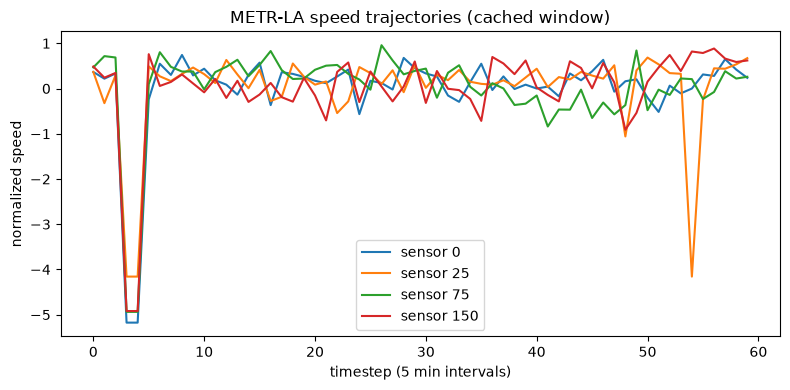

In [3]:
sensor_ids = [0, 25, 75, 150]
times = torch.arange(data_sequence.num_timesteps)

fig, ax = plt.subplots(figsize=(8, 4))
for sensor_id in sensor_ids:
    values = torch.stack([snap.x[sensor_id, 0] for snap in data_sequence])
    ax.plot(times, values.numpy(), label=f"sensor {sensor_id}")
ax.set_xlabel("timestep (5 min intervals)")
ax.set_ylabel("normalized speed")
ax.set_title("METR-LA speed trajectories (cached window)")
ax.legend()
fig.tight_layout()
plt.show()

## Build the graph Koopman model

We use a GCN encoder/decoder sized for one speed feature on 207 sensors.

In [4]:
in_channels = data_sequence.in_channels
hidden_channels = 64
latent_dim = 64

encoder = GNNEncoder(in_channels, hidden_channels, latent_dim)
decoder = GNNDecoder(latent_dim, hidden_channels, in_channels)
model = GraphKoopmanModel(
    encoder=encoder,
    decoder=decoder,
    latent_dim=latent_dim,
    time_step=5.0,
)

print(model)

GraphKoopmanModel(
  (encoder): GNNEncoder(
    (activation): ReLU()
    (convs): ModuleList(
      (0): GCNConv(1, 64)
      (1): GCNConv(64, 64)
    )
  )
  (decoder): GNNDecoder(
    (activation): ReLU()
    (convs): ModuleList(
      (0): GCNConv(64, 64)
      (1): GCNConv(64, 1)
    )
  )
  (koopman): KoopmanOperator()
)


## Gaussian edge weights on the road network

The cached METR-LA loader keeps the **Gaussian-kernel weighted adjacency** from
DCRNN: each directed road segment carries a scalar `edge_weight` aligned with
`edge_index`. GCN encoder and decoder layers pass these weights to PyG's
`GCNConv`, so nearby sensors with stronger road connectivity exchange more
information during lifting and reconstruction.

Unweighted graphs still work (all edges treated equally), but this tutorial
trains on the weighted METR-LA graph by default.

In [5]:
edge_weight = data_sequence.edge_weight
assert edge_weight is not None, "METR-LA sequence should retain Gaussian edge weights"

print(f"edge_weight shape: {tuple(edge_weight.shape)}")
print(
    f"edge_weight range: [{edge_weight.min().item():.4f}, {edge_weight.max().item():.4f}]"
)

train_snapshot = split.train[0]
with torch.no_grad():
    z_weighted = encoder(
        train_snapshot.x,
        train_snapshot.edge_index,
        train_snapshot.edge_weight,
    )
    z_unweighted = encoder(train_snapshot.x, train_snapshot.edge_index)

latent_mse = torch.mean((z_weighted - z_unweighted) ** 2).item()
print(f"Mean latent MSE (weighted vs unweighted encode): {latent_mse:.6f}")

edge_weight shape: (3444,)
edge_weight range: [0.0000, 1.0000]
Mean latent MSE (weighted vs unweighted encode): 0.000312


## Train the graph model

We hold out the earliest 70% of snapshots for training, the next 10% for
validation, and the final 20% for test evaluation. `fit` optimizes a weighted
sum of one-step reconstruction, forward consistency, and an autoregressive
rollout term that matches `predict`.

Reported **loss is not test MSE**. With `rollout=1.0`, the rollout term still
dominates early training because it measures multi-step error from a single
origin. Train loss is also anchored to the volatile start of the 42-step
training window, while the 6-step validation slice comes from a calmer period,
so validation loss can start much lower and then rise as the model adapts to the
training window. Early stopping monitors validation loss by default and may
restore epoch-0 weights on this short cache.

In [6]:
requested_horizons = (1, 2, 3) if os.environ.get("PYTEST_CURRENT_TEST") else (3, 6, 12)
max_eval_horizon = split.test.num_timesteps - 1
eval_horizons = tuple(h for h in requested_horizons if h <= max_eval_horizon)
if not eval_horizons:
    raise ValueError(
        f"test split has {split.test.num_timesteps} timesteps; "
        f"need at least {min(requested_horizons) + 1} for evaluation"
    )
predict_steps = max(eval_horizons)
rollout_horizon = min(
    predict_steps,
    min(split.train.num_timesteps, split.val.num_timesteps) - 1,
)
EPOCHS = 40 if os.environ.get("PYTEST_CURRENT_TEST") else 200
loss_weights = constant_loss_weights(
    reconstruction=1.0,
    forward=1.0,
    rollout=1.0,
)

torch.manual_seed(0)
history = model.fit(
    split.train,
    validation_sequence=split.val,
    epochs=EPOCHS,
    lr=1e-3,
    loss_weights=loss_weights,
    rollout_horizon=rollout_horizon,
    max_grad_norm=1.0,
    early_stopping_patience=20,
    restore_best_weights=True,
)

print(f"Initial train loss: {history.loss[0]:.6f}")
print(f"Final train loss: {history.loss[-1]:.6f}")
print(
    "Initial train breakdown: "
    f"recon={history.reconstruction_loss[0]:.4f}, "
    f"forward={history.forward_loss[0]:.4f}, "
    f"rollout={history.rollout_loss[0]:.4f}"
)
print(
    "Final train breakdown: "
    f"recon={history.reconstruction_loss[-1]:.4f}, "
    f"forward={history.forward_loss[-1]:.4f}, "
    f"rollout={history.rollout_loss[-1]:.4f}"
)
if history.val_loss is not None:
    print(f"Initial val loss: {history.val_loss[0]:.6f}")
    print(f"Final val loss: {history.val_loss[-1]:.6f}")
    best_val_epoch = history.val_loss.index(min(history.val_loss))
    print(
        f"Best validation epoch: {best_val_epoch} "
        f"(loss={history.val_loss[best_val_epoch]:.6f})"
    )

Initial train loss: 11.463734
Final train loss: 7.951339
Initial train breakdown: recon=1.3922, forward=0.0144, rollout=10.0571
Final train breakdown: recon=1.5225, forward=0.0158, rollout=6.4131
Initial val loss: 0.316156
Final val loss: 1.252217
Best validation epoch: 0 (loss=0.316156)


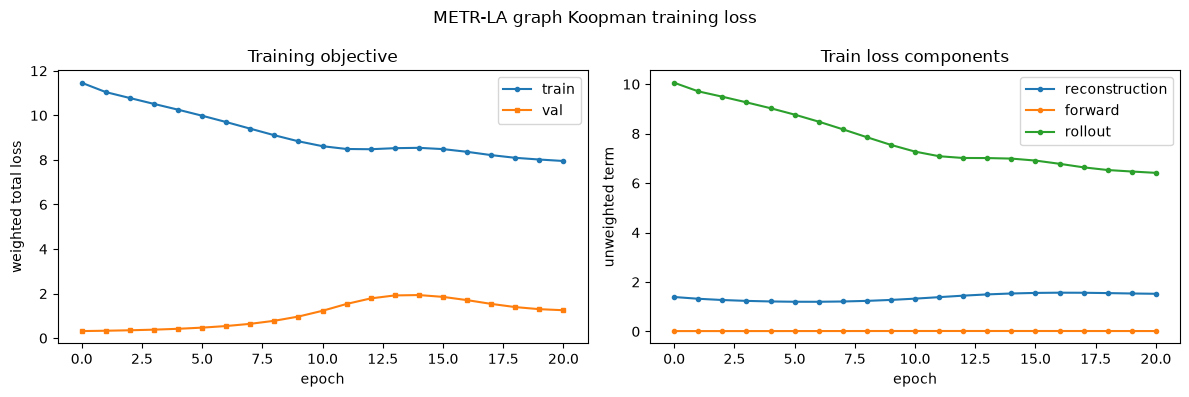

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.loss, marker="o", markersize=3, label="train")
if history.val_loss is not None:
    axes[0].plot(history.val_loss, marker="s", markersize=3, label="val")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted total loss")
axes[0].set_title("Training objective")
axes[0].legend()

axes[1].plot(history.reconstruction_loss, marker="o", markersize=3, label="reconstruction")
axes[1].plot(history.forward_loss, marker="o", markersize=3, label="forward")
axes[1].plot(history.rollout_loss, marker="o", markersize=3, label="rollout")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("unweighted term")
axes[1].set_title("Train loss components")
axes[1].legend()

fig.suptitle("METR-LA graph Koopman training loss")
fig.tight_layout()
plt.show()

## Evaluate on the held-out test split

`evaluate` reports MAE, RMSE, and MAPE at standard forecast horizons (3/6/12
when the test split is long enough). The bundled 60-snapshot cache yields a
12-step test window, so horizons are capped to those that fit (typically 3 and
6). Metrics are averaged over all valid forecast origins in the test split.

In [8]:
result = model.evaluate(split.test, horizons=eval_horizons)
for metric in result.horizons:
    print(
        f"horizon {metric.horizon:>2}: "
        f"MAE={metric.mae:.4f}, RMSE={metric.rmse:.4f}, MAPE={metric.mape:.4f}"
    )
print(
    f"Aggregate over horizons: "
    f"MAE={result.aggregate_mae:.4f}, "
    f"RMSE={result.aggregate_rmse:.4f}, "
    f"MAPE={result.aggregate_mape:.4f}"
)

initial_graph = split.test[0]
future_graphs = model.predict(initial_graph, steps=predict_steps)
ground_truth = split.test[1 : predict_steps + 1]
graph_mse = torch.mean(
    torch.stack(
        [
            torch.mean((pred.x - truth.x) ** 2)
            for pred, truth in zip(future_graphs, ground_truth, strict=True)
        ]
    )
)
print(f"Single-origin rollout MSE (for plotting): {graph_mse.item():.6f}")

horizon  3: MAE=0.3252, RMSE=0.4742, MAPE=1.5678
horizon  6: MAE=0.3764, RMSE=0.5205, MAPE=1.4673
Aggregate over horizons: MAE=0.3508, RMSE=0.4974, MAPE=1.5175
Single-origin rollout MSE (for plotting): 0.202033


## DMD and EDMD baselines

Classical Koopman pipelines ignore graph structure: all sensor speeds are
concatenated into one vector $v_t \in \mathbb{R}^{N}$ and fit with Dynamic Mode
Decomposition (DMD), $v_{t+1} \approx v_t K^\top$.

The packaged **`DMDBaseline`** solves this linear map directly by least
squares. **`EDMDBaseline`** extends DMD with polynomial observables in the
flattened state space before fitting the linear operator — a stronger
topology-agnostic reference that still ignores message passing on `edge_index`.

Neither baseline uses gradient training. The comparison highlights when
graph-aware encoding and decoding help congestion propagate along the road
network rather than arbitrary sensor index order.

In [9]:
baseline = DMDBaseline(time_step=1.0).fit(split.train)
edmd_baseline = EDMDBaseline(time_step=1.0, polynomial_degree=2).fit(split.train)

baseline_graphs = baseline.predict(split.test[0], steps=predict_steps)
edmd_graphs = edmd_baseline.predict(split.test[0], steps=predict_steps)
baseline_preds = [graph.x for graph in baseline_graphs]
edmd_preds = [graph.x for graph in edmd_graphs]


def rollout_mse(
    preds: list[torch.Tensor],
    truths: list,
) -> torch.Tensor:
    return torch.mean(
        torch.stack(
            [
                torch.mean((pred - truth.x) ** 2)
                for pred, truth in zip(preds, truths, strict=True)
            ]
        )
    )


def per_sensor_rollout_mse(
    preds: list[torch.Tensor],
    truths: list,
) -> torch.Tensor:
    return torch.mean(
        torch.stack(
            [
                ((pred - truth.x) ** 2).squeeze(-1)
                for pred, truth in zip(preds, truths, strict=True)
            ]
        ),
        dim=0,
    )


baseline_mse = rollout_mse(baseline_preds, ground_truth)
edmd_mse = rollout_mse(edmd_preds, ground_truth)
graph_per_sensor = per_sensor_rollout_mse(
    [graph.x for graph in future_graphs],
    ground_truth,
)
baseline_per_sensor = per_sensor_rollout_mse(baseline_preds, ground_truth)
edmd_per_sensor = per_sensor_rollout_mse(edmd_preds, ground_truth)
graph_wins = (graph_per_sensor < baseline_per_sensor) & (
    graph_per_sensor < edmd_per_sensor
)

print(f"DMD baseline rollout MSE:  {baseline_mse.item():.6f}")
print(f"EDMD baseline rollout MSE: {edmd_mse.item():.6f}")
print(f"Graph Koopman rollout MSE: {graph_mse.item():.6f}")
print(
    f"Per-sensor wins (graph < both baselines): "
    f"{int(graph_wins.sum())} / {graph_per_sensor.numel()} sensors"
)
if graph_mse < min(baseline_mse, edmd_mse):
    print("Graph model wins on this cached window (lowest MSE).")
elif edmd_mse < baseline_mse:
    print("EDMD baseline wins on this cached window (lowest MSE).")
else:
    print("DMD baseline wins on this cached window (lowest MSE).")

DMD baseline rollout MSE:  0.419547
EDMD baseline rollout MSE: 0.371059
Graph Koopman rollout MSE: 0.202033
Per-sensor wins (graph < both baselines): 174 / 207 sensors
Graph model wins on this cached window (lowest MSE).


## Visualize representative rollouts

Rollout MSE above averages over all sensors and timesteps. A single sensor can
look much worse than the baselines while the graph model still wins overall:
the graph Koopman rollout often collapses toward a low-variance level, which
helps on many sensors but fails on volatile ones. The figure below contrasts a
sensor where the graph model wins with sensor 75 from the trajectory plot.

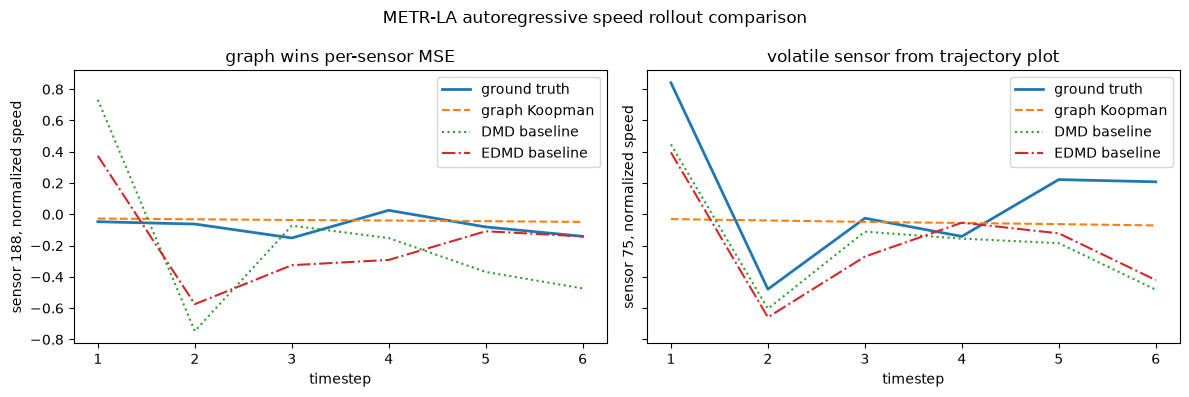

In [10]:
def rollout_series(
    preds: list[torch.Tensor],
    truths: list,
    sensor_id: int,
) -> tuple[torch.Tensor, torch.Tensor]:
    pred_values = torch.stack([pred[sensor_id, 0] for pred in preds])
    truth_values = torch.stack([truth.x[sensor_id, 0] for truth in truths])
    return pred_values, truth_values


if graph_wins.any():
    winning_mse = torch.where(
        graph_wins,
        graph_per_sensor,
        torch.full_like(graph_per_sensor, float("inf")),
    )
    representative_sensor = int(winning_mse.argmin())
else:
    representative_sensor = 0
volatile_sensor = 75
pred_times = torch.arange(1, predict_steps + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, sensor_id, subtitle in zip(
    axes,
    (representative_sensor, volatile_sensor),
    ("graph wins per-sensor MSE", "volatile sensor from trajectory plot"),
    strict=True,
):
    graph_values, truth_values = rollout_series(
        [graph.x for graph in future_graphs],
        ground_truth,
        sensor_id,
    )
    baseline_values, _ = rollout_series(baseline_preds, ground_truth, sensor_id)
    edmd_values, _ = rollout_series(edmd_preds, ground_truth, sensor_id)

    ax.plot(pred_times, truth_values.numpy(), label="ground truth", linewidth=2)
    ax.plot(pred_times, graph_values.numpy(), label="graph Koopman", linestyle="--")
    ax.plot(pred_times, baseline_values.numpy(), label="DMD baseline", linestyle=":")
    ax.plot(pred_times, edmd_values.numpy(), label="EDMD baseline", linestyle="-.")
    ax.set_xlabel("timestep")
    ax.set_ylabel(f"sensor {sensor_id}, normalized speed")
    ax.set_title(subtitle)
    ax.legend()

fig.suptitle("METR-LA autoregressive speed rollout comparison")
fig.tight_layout()
plt.show()

## Windowed mini-batch throughput

Long trajectories can use fixed-length temporal windows to trade one expensive
full-sequence optimizer update for several shorter updates. The benchmark below
reports optimizer-update throughput on the cached METR-LA training split. Exact
numbers depend on hardware; the windowed path is especially useful when
`windows_per_epoch` caps work on datasets much longer than this bundled sample.

In [11]:
import copy
import math
import time

benchmark_epochs = 1
window_length = min(12, split.train.num_timesteps)
valid_windows = split.train.num_timesteps - window_length + 1
sampled_windows = min(8, valid_windows)

full_probe = copy.deepcopy(model)
started = time.perf_counter()
full_probe.fit(split.train, epochs=benchmark_epochs, lr=1e-3)
full_seconds = time.perf_counter() - started

window_probe = copy.deepcopy(model)
started = time.perf_counter()
window_probe.fit(
    split.train,
    epochs=benchmark_epochs,
    lr=1e-3,
    window_length=window_length,
    batch_size=1,
    windows_per_epoch=sampled_windows,
    window_seed=0,
)
window_seconds = time.perf_counter() - started

full_updates = benchmark_epochs
window_updates = benchmark_epochs * math.ceil(sampled_windows / 1)
print(f"Full sequence: {full_updates / full_seconds:.2f} optimizer updates/s")
print(f"Windowed:      {window_updates / window_seconds:.2f} optimizer updates/s")
print(f"Windowed path used {sampled_windows} of {valid_windows} valid windows")

Full sequence: 2.16 optimizer updates/s
Windowed:      7.44 optimizer updates/s
Windowed path used 8 of 31 valid windows


## Next steps

- See [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) for a smaller
  synthetic graph walkthrough.
- See [`02_ieee118_bus.ipynb`](02_ieee118_bus.ipynb) for a smart-grid example
  on the IEEE 118-bus network.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html)
  for loss weights, early stopping, and GAT encoders.